In [2]:
!pip install pandas numpy seaborn matplotlib

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv("diabetic_data.csv")

In [22]:
df.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [23]:
df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [24]:
#Checking for missing values 
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values.head(20)

max_glu_serum          96420
A1Cresult              84748
encounter_id               0
nateglinide                0
glimepiride                0
acetohexamide              0
glipizide                  0
glyburide                  0
tolbutamide                0
pioglitazone               0
rosiglitazone              0
acarbose                   0
miglitol                   0
troglitazone               0
tolazamide                 0
examide                    0
citoglipton                0
insulin                    0
glyburide-metformin        0
glipizide-metformin        0
dtype: int64

In [25]:
(df == "?").sum().sort_values(ascending=False)

weight                      98569
medical_specialty           49949
payer_code                  40256
race                         2273
diag_3                       1423
diag_2                        358
diag_1                         21
encounter_id                    0
tolazamide                      0
glyburide                       0
tolbutamide                     0
pioglitazone                    0
rosiglitazone                   0
acarbose                        0
miglitol                        0
troglitazone                    0
citoglipton                     0
examide                         0
acetohexamide                   0
insulin                         0
glyburide-metformin             0
glipizide-metformin             0
glimepiride-pioglitazone        0
metformin-rosiglitazone         0
metformin-pioglitazone          0
change                          0
diabetesMed                     0
glipizide                       0
repaglinide                     0
glimepiride   

In [26]:
df = df.drop(columns=["encounter_id","patient_nbr"])

In [27]:
df = df.replace("?", np.nan)

In [28]:
df = df.drop(columns=["weight","payer_code","medical_specialty"])

In [29]:
df["readmitted"] = df["readmitted"].replace({
    ">30":0,
    "<30":1,
    "NO":0
})

/var/folders/mv/m_x9c2c514gbf1p4df0xwxdm0000gn/T/ipykernel_14768/4058477148.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["readmitted"] = df["readmitted"].replace({


Text(0.5, 1.0, 'Distribution of Hospital Stay Length')

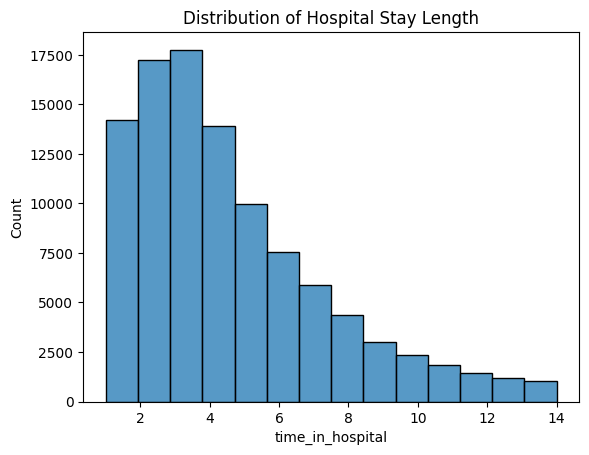

In [30]:
sns.histplot(df["time_in_hospital"], bins=14)
plt.title("Distribution of Hospital Stay Length")

<Axes: xlabel='count', ylabel='age'>

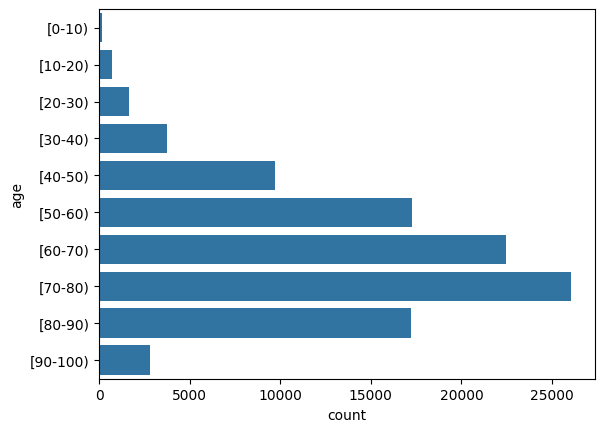

In [31]:
sns.countplot(y="age", data=df)

<Axes: xlabel='readmitted', ylabel='count'>

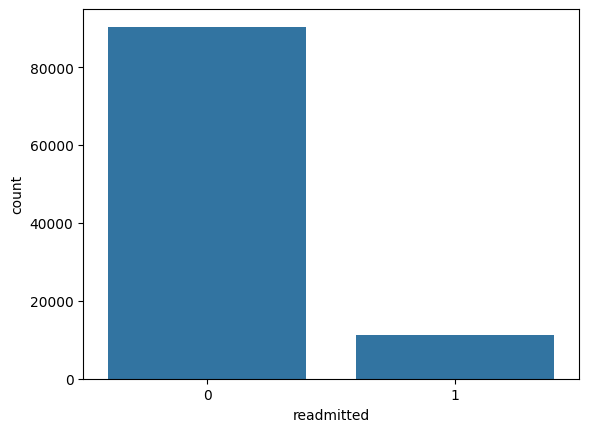

In [32]:
sns.countplot(x="readmitted", data=df)

<Axes: xlabel='readmitted', ylabel='time_in_hospital'>

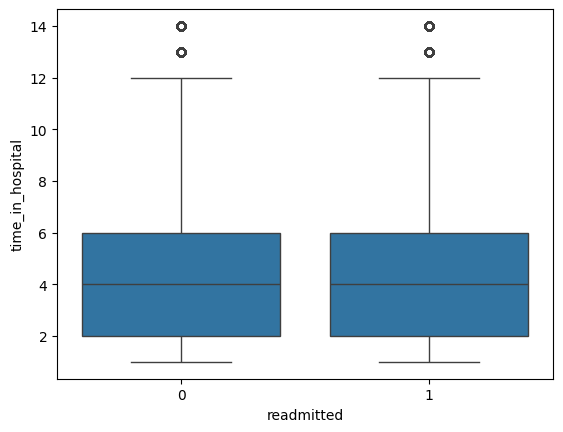

In [33]:
sns.boxplot(x="readmitted", y="time_in_hospital", data=df)

<Axes: xlabel='readmitted', ylabel='num_medications'>

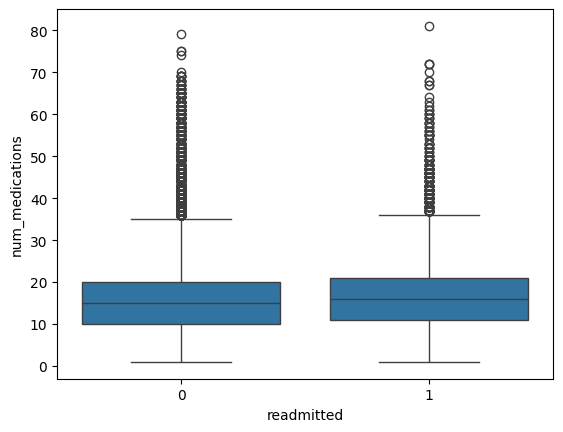

In [34]:
sns.boxplot(x="readmitted", y="num_medications", data=df)